# 25_01 머신러닝 최소 개념

In [3]:
# [환경 설정] 한글 폰트 설정 및 필수 라이브러리 로드
# macOS, Windows, Linux, Google Colab 환경에 맞춰 한글 깨짐 없이 동작하도록 자동 감지 설정합니다.

import platform
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np

try:
    import seaborn as sns
except ImportError:
    pass

# 운영체제(OS)별 한글 폰트 자동 설정
system_name = platform.system()
if system_name == 'Darwin':          # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'DejaVu Sans']
elif system_name == 'Windows':       # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'NanumGothic', 'DejaVu Sans']
else:                               # Linux / Google Colab
    try:
        nanum_fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
        if nanum_fonts:
            plt.rcParams['font.family'] = nanum_fonts[0]
        else:
            import subprocess
            subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], check=False, stdout=subprocess.DEVNULL)
            fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
            plt.rcParams['font.family'] = 'NanumGothic'
    except Exception:
        pass
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'DejaVu Sans']

# 마이너스 기호 깨짐 방지 및 Seaborn 폰트 동기화
plt.rcParams['axes.unicode_minus'] = False
try:
    if 'sns' in locals():
        sns.set_theme(style='whitegrid', font=plt.rcParams['font.family'])
except Exception:
    pass

print(f'✅ 환경 설정 완료! 현재 적용된 폰트: {plt.rcParams["font.family"]}')

✅ 환경 설정 완료! 현재 적용된 폰트: ['AppleGothic']


## 실습 1. 오디오 특징을 X와 y로 나누기
### 목표
오디오 특징 데이터를 특징(X)과 정답(y)으로 나누되 정답 열을 X에 넣지 않기
### 단계
- 정답 열을 y로 분리
- 세 특징 열만 골라 X로 분리
- X와 y의 모양을 확인하고 X에 정답이 없는지 점검
### 예상 결과
X는 104행 3열, y는 104개, X에 정답 열 없음


In [4]:
# 실습1 코드
df = pd.read_csv("data/25_mimii_features.csv", encoding="UTF-8")

y = df["label"]
X = df[["rms", "spectral_centroid", "zero_crossing_rate"]]

print(X.shape)
print(y.shape)

(104, 3)
(104,)


## 실습 2. 설비 센서를 X와 y로 나누기
### 목표
설비 센서 데이터에서 고장 임박 여부를 정답으로, 무관한 열을 빼고 특징을 나누기
### 단계
- 고장 임박 여부 열을 정답 y로 분리
- 회차와 센서 열만 특징 X로 고르고 정답·무관한 열은 제외
- 정답의 값 분포와 X 모양을 확인
### 예상 결과
X는 40행 2열, 정답은 정상 32·임박 8, X에 정답·RUL 없음


In [5]:
# 실습2 코드

sm = pd.read_csv("data/25_cmapss_sample.csv")

y = sm["failure_soon"]
X = sm[["cycle", "sensor_2"]]

print(X.shape)
print(y.shape)

print("정답분포 :" "failure_soon" in X.columns)

(40, 2)
(40,)
False


# 25_02 이상탐지와 통계 기초

In [6]:
# [환경 설정] 한글 폰트 설정 및 필수 라이브러리 로드
# macOS, Windows, Linux, Google Colab 환경에 맞춰 한글 깨짐 없이 동작하도록 자동 감지 설정합니다.

import platform
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np

try:
    import seaborn as sns
except ImportError:
    pass

# 운영체제(OS)별 한글 폰트 자동 설정
system_name = platform.system()
if system_name == 'Darwin':          # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'DejaVu Sans']
elif system_name == 'Windows':       # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'NanumGothic', 'DejaVu Sans']
else:                               # Linux / Google Colab
    try:
        nanum_fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
        if nanum_fonts:
            plt.rcParams['font.family'] = nanum_fonts[0]
        else:
            import subprocess
            subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], check=False, stdout=subprocess.DEVNULL)
            fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
            plt.rcParams['font.family'] = 'NanumGothic'
    except Exception:
        pass
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'DejaVu Sans']

# 마이너스 기호 깨짐 방지 및 Seaborn 폰트 동기화
plt.rcParams['axes.unicode_minus'] = False
try:
    if 'sns' in locals():
        sns.set_theme(style='whitegrid', font=plt.rcParams['font.family'])
except Exception:
    pass

print(f'✅ 환경 설정 완료! 현재 적용된 폰트: {plt.rcParams["font.family"]}')

✅ 환경 설정 완료! 현재 적용된 폰트: ['AppleGothic']


## 실습 1. 정상 데이터의 평균·표준편차
### 목표
정상 데이터만 골라 중심인 평균과 산포인 표준편차를 구하기
### 단계
- 정답이 정상인 행만 골라내기
- 정상 데이터의 평균을 구해 중심 확인
- 정상 데이터의 표준편차를 구해 흩어짐 확인
### 예상 결과
정상 96개, 평균 약 0.1015, 표준편차 약 0.0184

In [7]:
# 실습1 코드
# df = "data/25_mimii_features.csv"

normal = df[df["label"] ==0]
normal.head()

print(f"정상 개수 : {len(normal)}")
print(f"평균 : {round(normal["rms"].mean(), 4)}")
print(f"표준편차 : {round(normal["rms"].std(), 4)}")


정상 개수 : 96
평균 : 0.1015
표준편차 : 0.0184


## 실습 2. 정상 범위 계산 (평균±3σ)
### 목표
정상 평균에 표준편차 세 배를 더하고 빼 정상으로 볼 범위를 정하기
### 단계
- 정상 데이터의 평균과 표준편차를 준비
- 평균에서 표준편차 세 배만큼 아래·위로 벌려 범위를 만들기
- 이 범위를 벗어난 값을 이상 후보로 보기
### 예상 결과
정상 범위 약 0.046~0.157, 이 밖이면 이상 후보


In [8]:
# 실습2 코드
m = normal["rms"].mean()
s = normal["rms"].std()

lo, hi = (m-3*s), (m+3*s)

print("정상범위 :", round(lo, 3), "~", round(hi, 3))

정상범위 : 0.046 ~ 0.157


### 실습 3. 분포 히스토그램·박스플롯 관찰
### 목표
히스토그램과 박스플롯으로 데이터 분포와 튀는 값을 관찰
### 단계
- 한 특징의 히스토그램을 그려 값이 몰린 위치 보기
- 같은 특징의 박스플롯을 그려 상자 밖 점 확인
- 정상은 몰리고 이상은 꼬리로 떨어짐을 관찰
### 예상 결과
정상은 낮은 값에 몰리고, 이상은 오른쪽 꼬리로 떨어져 나옴

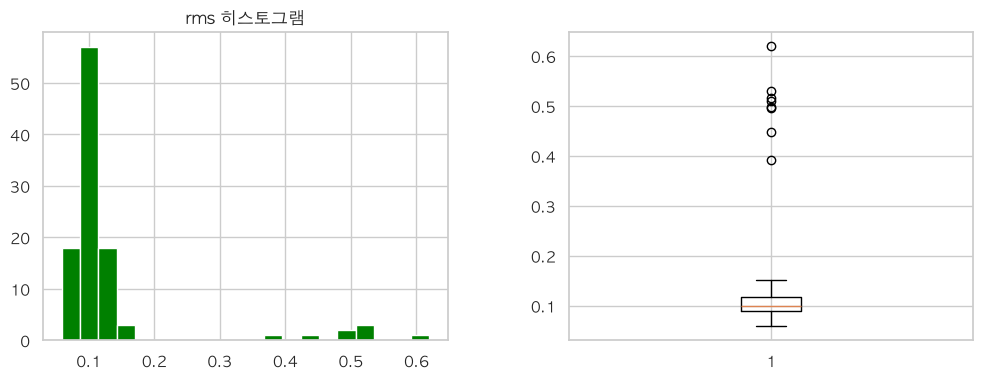

In [9]:
# 실습3 코드

plt.figure(figsize=(12, 4))
plt.subplots_adjust(wspace=0.3, hspace=0.5)  # 간격조정
plt.subplot(1,2,1)
plt.hist(df["rms"], bins=20, color = "green")
plt.title("rms 히스토그램")

plt.subplot(1, 2, 2)
plt.boxplot(df["rms"])
plt.show()

## 실습 4. 센서별 정상·이상 통계 비교
### 목표
특징마다 정상 그룹과 이상 그룹의 평균을 비교해 감별력을 보기
### 단계
· 정답이 이상인 행만 따로 골라내기
· 세 특징마다 정상 평균과 이상 평균을 나란히 출력
· 두 평균 차이가 큰 특징을 좋은 감별 특징으로 선별
### 예상 결과
세 특징 모두 이상 평균이 크게 높아 잘 갈림


In [10]:
abnormal = df[df["label"]== 1]

for col in ['rms', 'spectral_centroid', 'zero_crossing_rate']:
    print(col, "정상", round(normal[col].mean(),3))
    print(" 이상", round(abnormal[col].mean(),3))

rms 정상 0.101
 이상 0.501
spectral_centroid 정상 1784.023
 이상 2871.663
zero_crossing_rate 정상 0.081
 이상 0.222


# 25_03 Z-score 기반 이상치 탐색

In [11]:
# [환경 설정] 한글 폰트 설정 및 필수 라이브러리 로드
# macOS, Windows, Linux, Google Colab 환경에 맞춰 한글 깨짐 없이 동작하도록 자동 감지 설정합니다.

import platform
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np

try:
    import seaborn as sns
except ImportError:
    pass

# 운영체제(OS)별 한글 폰트 자동 설정
system_name = platform.system()
if system_name == 'Darwin':          # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'DejaVu Sans']
elif system_name == 'Windows':       # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'NanumGothic', 'DejaVu Sans']
else:                               # Linux / Google Colab
    try:
        nanum_fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
        if nanum_fonts:
            plt.rcParams['font.family'] = nanum_fonts[0]
        else:
            import subprocess
            subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], check=False, stdout=subprocess.DEVNULL)
            fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
            plt.rcParams['font.family'] = 'NanumGothic'
    except Exception:
        pass
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'DejaVu Sans']

# 마이너스 기호 깨짐 방지 및 Seaborn 폰트 동기화
plt.rcParams['axes.unicode_minus'] = False
try:
    if 'sns' in locals():
        sns.set_theme(style='whitegrid', font=plt.rcParams['font.family'])
except Exception:
    pass

print(f'✅ 환경 설정 완료! 현재 적용된 폰트: {plt.rcParams["font.family"]}')

✅ 환경 설정 완료! 현재 적용된 폰트: ['AppleGothic']


## 실습 1. 손으로 Z-score 계산·판정
### 목표
정상 다섯 값으로 평균·표준편차를 구해 새 값의 Z-score를 손으로 계산·판정
### 단계
- 정상 다섯 값의 평균과 표준편차를 구하기
- 새 값마다 평균을 빼고 표준편차로 나눠 Z를 구하기
- 절댓값이 기준을 넘으면 이상으로 판정
### 예상 결과
53은 약 1.9, 68은 약 11.4, 40은 약 -6.3


In [12]:
# 실습1 코드

vals = np.array([48, 50, 52, 49, 51])
m = vals.mean()
s = vals.std(ddof=1) # ddof=0이 기본 / 1은 표본표준편차 기준으로 편향을 보정

print("평균 :", m)
print("표준편차 :",round(s,4))

for v in [53, 68, 40]:
    print(v, "-> Z =", round( (v-m)/s,2))

평균 : 50.0
표준편차 : 1.5811
53 -> Z = 1.9
68 -> Z = 11.38
40 -> Z = -6.32


## 실습 2. 정상 데이터 기준 통계량 계산
### 목표
데이터를 불러와 구조를 확인하고 정상만 골라 이상 판정 기준 통계량을 계산
### 단계
- 파일을 불러와 크기와 정답 분포 확인
- 정답이 정상인 행만 골라내기
- 정상의 평균과 표준편차를 이상 판정 기준으로 삼기
### 예상 결과
정상 96·이상 8, 정상 평균 0.1015·표준편차 0.0184

In [16]:
# 실습2 코드

MI = "data/26_mimii_features.csv"

df = pd.read_csv(MI, encoding="UTF-8")
print("shape ", df.shape,"\n라벨", df["label"].value_counts().to_dict())

normal = df[df["label"] == 0]
rms_mean = normal["rms"].mean()
rms_std = normal["rms"].std()

print(f"정상 평균 : {round(rms_mean,4)} 정상 표준편차 : {round(rms_std,4)}")

shape  (220, 4) 
라벨 {0: 180, 1: 40}
정상 평균 : 0.05 정상 표준편차 : 0.0122


## 실습 3. Z-score 컬럼 만들기
### 목표
모든 행의 rms를 Z-score로 바꿔 새 열로 담기
### 단계
- 각 값에서 정상 평균을 빼고 정상 표준편차로 나누기
- 절댓값을 취해 방향과 무관하게 벗어난 정도로 만들기
- Z가 큰 상위 몇 개를 확인
### 예상 결과
Z 상위 세 값이 28.1·23.3·22.5로 매우 큼


In [19]:
# 실습3 코드

df["z_rms"] = np.abs((df["rms"]-rms_mean) /rms_std)

print("z 상위 :", df["z_rms"].round(1).nlargest(3).tolist())

z 상위 : [9.0, 7.9, 7.2]


## 실습 4. 임계값 기준 이상치 필터링
### 목표
기준값을 넘는 Z-score를 이상치로 걸러내기
### 단계
- 이상 판정 기준을 3으로 정하기
- Z가 기준을 넘는 행만 골라내기
- 걸러진 이상치 개수를 확인
### 예상 결과
기준 3에서 이상치 8건

In [20]:
# 실습4 코드
threshold = 3.0
anomalies = df[df["z_rms"]>threshold]
print("이상치 개수 :", len(anomalies))

anomalies.head()

이상치 개수 : 23


,rms,spectral_centroid,zero_crossing_rate,label,z_rms
21,0.1308,1989.7,0.1159,1,6.621789
23,0.1250,2846.4,0.0687,1,6.146626
26,0.1353,2434.4,0.0679,1,6.990450
70,0.1599,1947.0,0.0891,1,9.005796
72,0.1267,2315.3,0.0909,1,6.285897


## 실습 5. 이상치 산점도 시각화
### 목표
순서대로 Z를 점으로 찍고 기준선을 그어 이상치를 눈으로 확인
### 단계
- 각 행 순서를 가로축, Z를 세로축으로 산점도 그리기
- 기준값 위치에 가로 점선 긋기
- 점선 위로 솟은 점을 이상치로 확인
### 예상 결과
대부분 낮게 깔리고 몇몇 점이 기준선 위로 크게 솟음


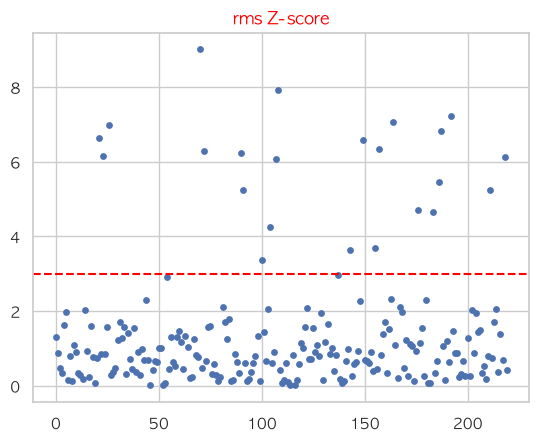

In [21]:
# 실습5 코드

plt.scatter(range(len(df)), df["z_rms"], s= 15)
plt.axhline(y=threshold, color = "red", linestyle="--")
plt.title("rms Z-score", color = "red")
plt.show()

## 실습 6. 다른 feature에도 Z-score 적용
### 목표
같은 방식을 다른 특징에도 적용해 이상치 개수를 비교
### 단계
- 다른 특징마다 정상 평균·표준편차로 Z를 계산
- 기준을 넘는 개수를 세기
- 특징별 탐지 개수를 비교
### 예상 결과
두 특징 모두 기준 3에서 이상치 8건

In [23]:
# 실습6 코드

cols = ["spectral_centroid", "zero_crossing_rate"]

for col in cols:
    col_mean = normal[col].mean()
    col_std = normal[col].std()
    z = np.abs((df[col] - col_mean) / col_std)
    print(col, "이상치:", int((z > threshold).sum()))

spectral_centroid 이상치: 16
zero_crossing_rate 이상치: 5


## 실습 7. Z-score 결과와 실제 label 비교
### 목표
Z-score 판정 결과를 실제 정답과 대조해 정탐·미탐·오탐을 세기
### 단계
- Z가 기준을 넘으면 이상으로 예측한 열 만들기
- 예측과 실제 정답을 짝지어 정탐·미탐·오탐 세기
- 셋의 균형으로 탐지 품질 확인
### 예상 결과
정탐 8·미탐 0·오탐 0으로 완벽 분리

In [24]:
# 실습7 코드
df["pred"] = (df["z_rms"] > threshold).astype(int)

tp = ((df["pred"] == 1) & (df["label"] == 1)).sum()
fn = ((df["pred"] == 0) & (df["label"] == 1)).sum()
fp = ((df["pred"] == 1) & (df["label"] == 0)).sum()
print("정탐:", int(tp), "미탐:", int(fn), "오탐:", int(fp))

정탐: 23 미탐: 17 오탐: 0


## 실습 8. 임계값 바꿔 결과 비교
### 목표
기준값을 바꿔 가며 탐지 개수가 어떻게 변하는지 비교
### 단계
- 여러 기준값을 준비
- 각 기준마다 넘는 개수를 세기
- 기준이 낮을수록 많이 잡힘을 확인
### 예상 결과
기준 2는 13건, 2.5는 9건, 3은 8건


In [ ]:
# 실습8 코드
for t in [2.0, 2.5, 3.0]:
    print("임계값", t, "→ 이상치", int((df["z_rms"] > t).sum()), "개")

## 실습 9. C-MAPSS 샘플로 Z-score 적용
### 목표
같은 Z-score 방법을 설비 센서 데이터에 적용
### 단계
- 초반 정상 구간을 기준으로 평균·표준편차 잡기
- 전체 회차의 센서 값을 Z로 변환
- Z가 큰 후반 상위 값을 확인
### 예상 결과
후반 Z 상위 세 값이 15.6·11.6·11.6으로 크게 벗어남


In [25]:
# 실습9 코드
CM = "data/25_cmapss_sample.csv"

cm = pd.read_csv(CM)

ref = cm[cm["cycle"] <= 20]

mc = ref["sensor_2"].mean()
sc = ref["sensor_2"].std()

cm["z"] = np.abs((cm["sensor_2"] - mc) / sc)

print("후반 z 상위:", cm["z"].round(1).nlargest(3).tolist())

후반 z 상위: [15.6, 11.6, 11.6]


## 실습 10. 종합 이상 구간 정비 리포트
### 목표
탐지 결과를 정비 리포트로 정리해 우선 점검 대상을 뽑기
### 단계
- 이상치 비율을 계산
- 점검 대상·기준·탐지 건수를 리포트로 출력
- Z 상위 몇 건을 최우선 점검으로 정리
### 예상 결과
이상 8건(약 7.7퍼센트), Z 상위 3건이 최우선 점검


In [26]:
# 실습10 코드
ratio = len(anomalies) / len(df) * 100

print("=== 이상 구간 정비 리포트 ===")
print("점검 대상: MIMII rms / 기준: |Z| >", threshold)
print("탐지:", len(anomalies), "건 (", round(ratio, 1), "%)")
print(anomalies.nlargest(3, "z_rms")[["rms", "z_rms"]].to_string(index=False))

=== 이상 구간 정비 리포트 ===
점검 대상: MIMII rms / 기준: |Z| > 3.0
탐지: 23 건 ( 10.5 %)
   rms    z_rms
0.1599 9.005796
0.1467 7.924391
0.1380 7.211646
